## Imports and env variables

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Simple BMI calculator

In [26]:
# define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    fit_category: str

In [39]:
# create node which executes a python function and updates state
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

def fit_category(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['fit_category'] = 'Underweight'
    elif bmi < 25:
        state['fit_category'] = 'Normal'
    elif bmi < 30:
        state['fit_category'] = 'Overweight'
    else:
        state['fit_category'] = 'Obese'
    return state

In [40]:
# define graph using the StateGraph class
graph = StateGraph(BMIState)

# add nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("fit_category", fit_category)

# add edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "fit_category")
graph.add_edge("fit_category", END)

# compile graph
worfklow = graph.compile()

In [48]:
## execute graph
initial_state = {"weight_kg": 70, "height_m": 1.7}
final_state = worfklow.invoke(initial_state)

In [49]:
print("Initial State:", initial_state)
print("Final State:", final_state)

Initial State: {'weight_kg': 70, 'height_m': 1.7}
Final State: {'weight_kg': 70, 'height_m': 1.7, 'bmi': 24.22, 'fit_category': 'Normal'}


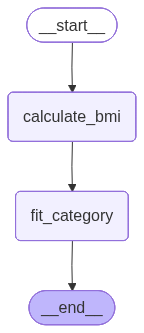

In [47]:
## Visualizing the graph
from IPython.display import Image
Image(worfklow.get_graph().draw_mermaid_png())